**Daniel Yu & Jordan Wang**

Spring 2026

CS 443: Bio-inspired Machine Learning

Project 2: Predictive Coding

#### Extension 1: Explore Other Image Completion Scenarios

For this extension we push the dense PCN image-completion demo beyond one fixed mask. We test several mask types and mask strengths, then compare how completion quality changes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
plt.rcParams.update({'font.size': 16})
np.set_printoptions(suppress=True, precision=3)

%load_ext autoreload
%autoreload 2

### Setup

We use MNIST and DensePCN because this model is naturally suited for flattened image completion experiments.

In [2]:
from image_datasets import get_dataset, train_val_split
from dense_pcn import DensePCN

In [3]:
x_train_full, y_train_full, x_test, y_test = get_dataset('mnist', norm_method='global', flatten=True)
x_train, y_train, x_val, y_val = train_val_split(x_train_full, y_train_full, prop_val=0.1)
print(f'Train: {x_train.shape}, Val: {x_val.shape}, Test: {x_test.shape}')

Dataset: mnist
x_train: (60000, 784) <dtype: 'float32'>
y_train: (60000,) <dtype: 'uint8'>
x_test:  (10000, 784) <dtype: 'float32'>
y_test:  (10000,) <dtype: 'uint8'>
Train: (54000, 784), Val: (6000, 784), Test: (10000, 784)


### Train DensePCN

We train once, then reuse the trained model across all completion scenarios.

In [4]:
quick_mode = False

if quick_mode:
    x_train_run, y_train_run = x_train[:12000], y_train[:12000]
    x_val_run, y_val_run = x_val[:2500], y_val[:2500]
    max_epochs = 20
else:
    x_train_run, y_train_run = x_train, y_train
    x_val_run, y_val_run = x_val, y_val
    max_epochs = 35

tf.random.set_seed(42)
pcn = DensePCN(
    input_feats_shape=(x_train.shape[1],),
    C=10,
    hidden_units=(256, 128),
    wt_scale=1e-2,
    gamma_lr=0.1,
    train_num_steps=20,
    test_num_steps=10
)
pcn.compile(loss='predictive', lr=1e-3, print_summary=False)

train_loss, val_loss, val_acc, epochs_used = pcn.fit(
    x_train_run, y_train_run,
    x_val=x_val_run, y_val=y_val_run,
    batch_size=256,
    max_epochs=max_epochs,
    patience=7,
    lr_patience=3,
    lr_decay_factor=0.7,
    lr_max_decays=3,
    verbose=True,
    print_every=1
)

print(f'Best val acc: {np.max(val_acc):.4f} at epoch {np.argmax(val_acc)+1}')

Epoch 0/34, Training loss 96.605160, Val loss 184.604584, Val acc 0.1899
Epoch 0 took: 32.1 secs
Epoch 1/34, Training loss 29.058254, Val loss 344.074585, Val acc 0.2145
Epoch 1 took: 32.5 secs
Epoch 2/34, Training loss 18.911597, Val loss 550.455200, Val acc 0.3935
Epoch 2 took: 32.1 secs
Learning rate before decay: <Variable path=adam/learning_rate, shape=(), dtype=float32, value=0.0010000000474974513>
Learning rate after decay: <Variable path=adam/learning_rate, shape=(), dtype=float32, value=0.0007000000332482159>
Epoch 3/34, Training loss 14.535301, Val loss 733.177429, Val acc 0.5304
Epoch 3 took: 32.3 secs
Epoch 4/34, Training loss 12.425178, Val loss 972.092163, Val acc 0.5894
Epoch 4 took: 32.3 secs
Epoch 5/34, Training loss 11.320251, Val loss 1270.665283, Val acc 0.6104
Epoch 5 took: 32.3 secs
Epoch 6/34, Training loss 10.553110, Val loss 1513.174438, Val acc 0.6174
Epoch 6 took: 32.6 secs
Learning rate before decay: <Variable path=adam/learning_rate, shape=(), dtype=float32

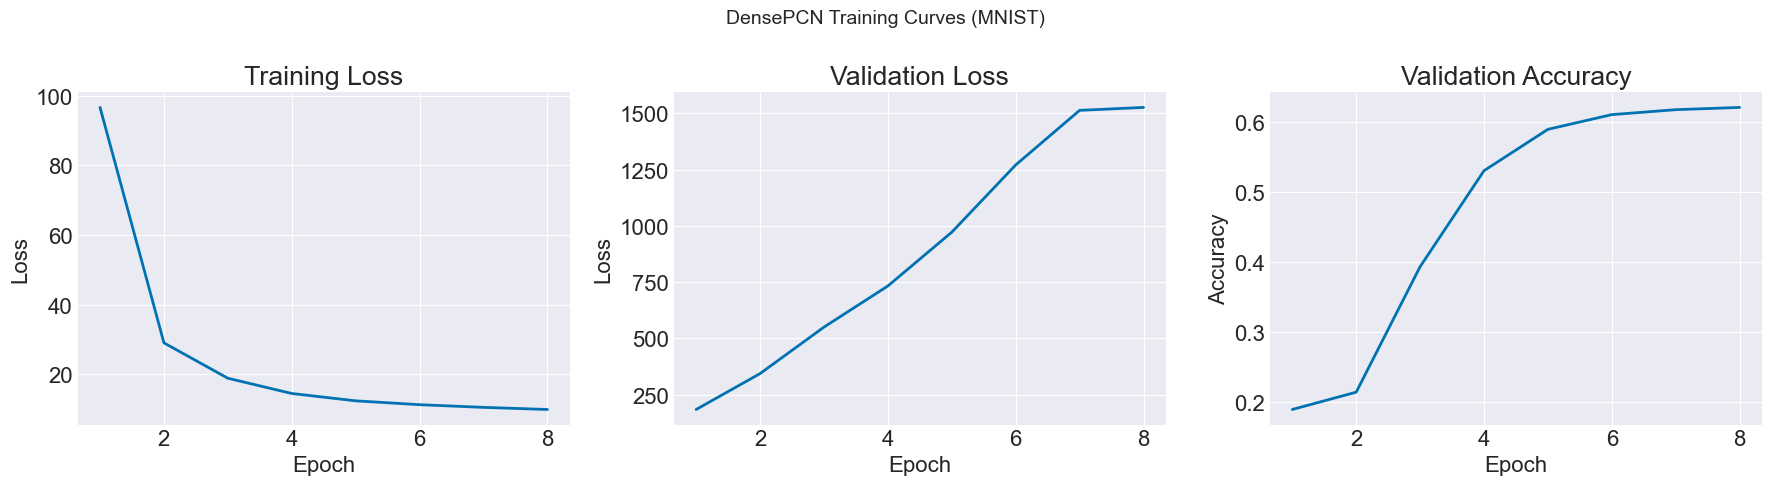

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epochs = np.arange(1, len(train_loss) + 1)
axes[0].plot(epochs, train_loss, linewidth=2)
axes[1].plot(epochs, val_loss, linewidth=2)
axes[2].plot(epochs, val_acc, linewidth=2)
axes[0].set_title('Training Loss')
axes[1].set_title('Validation Loss')
axes[2].set_title('Validation Accuracy')
for ax in axes:
    ax.set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[1].set_ylabel('Loss')
axes[2].set_ylabel('Accuracy')
plt.suptitle('DensePCN Training Curves (MNIST)', fontsize=14)
plt.tight_layout()
plt.show()

### Build Completion Batch (One Sample Per Class)

In [6]:
def one_sample_per_class(x, y, num_classes=10):
    idxs = []
    y_np = y.numpy() if hasattr(y, 'numpy') else np.asarray(y)
    for c in range(num_classes):
        idx = np.where(y_np == c)[0][0]
        idxs.append(idx)
    idxs = np.array(idxs, dtype=np.int32)
    return tf.gather(x, idxs), tf.gather(y, idxs)

x_batch, y_batch = one_sample_per_class(x_test, y_test, num_classes=10)
print(x_batch.shape, y_batch.shape)
print('Labels in batch:', y_batch.numpy())

(10, 784) (10,)
Labels in batch: [0 1 2 3 4 5 6 7 8 9]


### Mask Utilities

Mask format used by `complete_input`: 1 = keep pixel, 0 = masked pixel.

In [7]:
IMG_H, IMG_W = 28, 28

def mask_vertical(frac_keep=0.5):
    keep_cols = int(IMG_W * frac_keep)
    m = np.zeros((IMG_H, IMG_W), dtype=np.float32)
    m[:, :keep_cols] = 1.0
    return m.reshape(-1)

def mask_horizontal(frac_keep=0.5):
    keep_rows = int(IMG_H * frac_keep)
    m = np.zeros((IMG_H, IMG_W), dtype=np.float32)
    m[:keep_rows, :] = 1.0
    return m.reshape(-1)

def mask_stripes(period=4, keep_width=2):
    m = np.zeros((IMG_H, IMG_W), dtype=np.float32)
    for c in range(IMG_W):
        if (c % period) < keep_width:
            m[:, c] = 1.0
    return m.reshape(-1)

def mask_random(frac_keep=0.5, seed=0):
    rng = np.random.RandomState(seed)
    m = (rng.rand(IMG_H * IMG_W) < frac_keep).astype(np.float32)
    return m

def broadcast_mask(mask_flat, B):
    return tf.constant(np.repeat(mask_flat[None, :], B, axis=0), dtype=tf.float32)

### Scenario 1: Vertical Half Mask

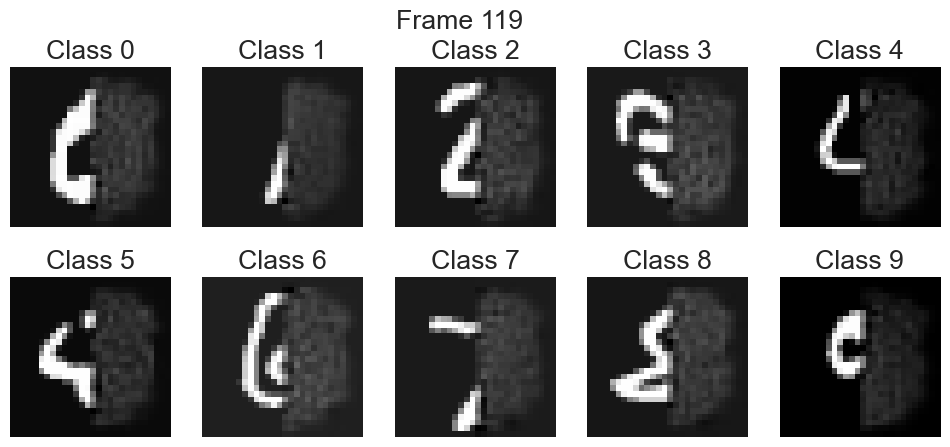

In [8]:
m = mask_vertical(frac_keep=0.5)
x_mask = broadcast_mask(m, B=len(x_batch))
x_masked = x_batch * x_mask
pcn.complete_input(x_masked, x_mask, y_batch, num_steps=120, image_dims=(28, 28, 1), n_plot_rows=2)

### Scenario 2: Horizontal Half Mask

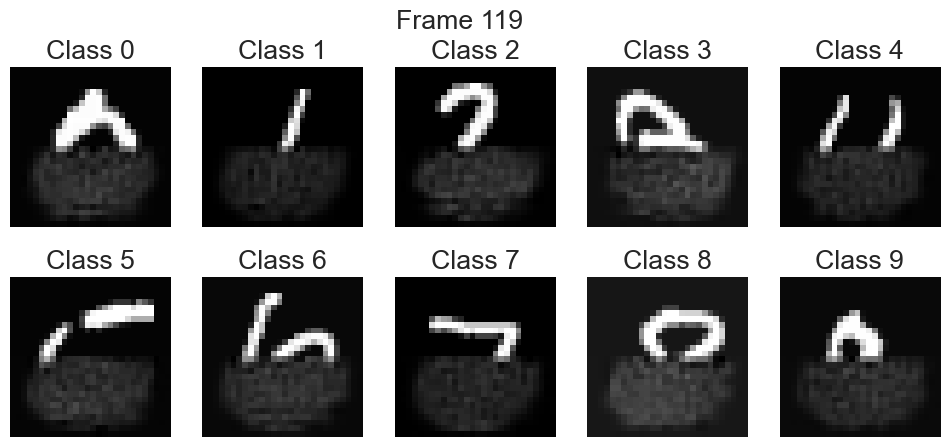

In [9]:
m = mask_horizontal(frac_keep=0.5)
x_mask = broadcast_mask(m, B=len(x_batch))
x_masked = x_batch * x_mask
pcn.complete_input(x_masked, x_mask, y_batch, num_steps=120, image_dims=(28, 28, 1), n_plot_rows=2)

### Scenario 3: Periodic Stripe Mask

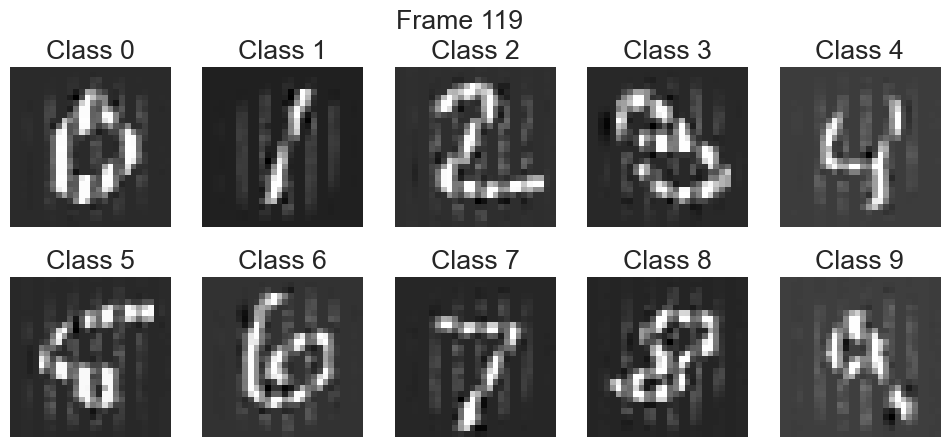

In [10]:
m = mask_stripes(period=4, keep_width=2)
x_mask = broadcast_mask(m, B=len(x_batch))
x_masked = x_batch * x_mask
pcn.complete_input(x_masked, x_mask, y_batch, num_steps=120, image_dims=(28, 28, 1), n_plot_rows=2)

### Scenario 4: Random Mask (50% keep)

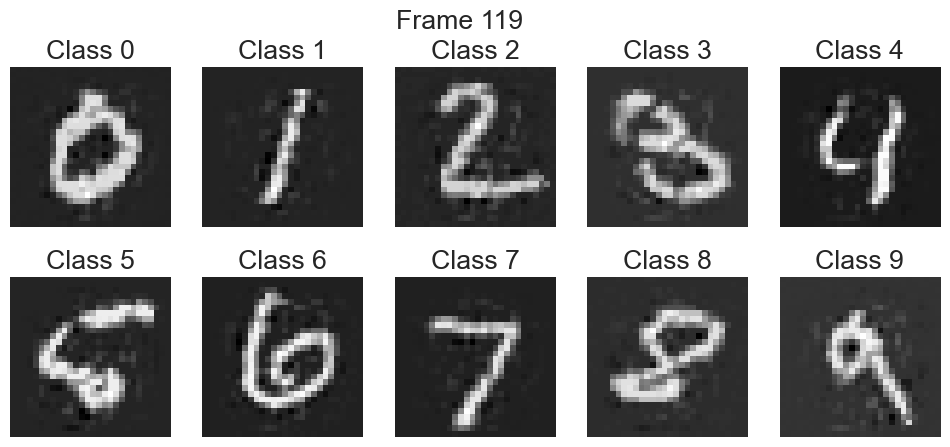

In [11]:
m = mask_random(frac_keep=0.5, seed=7)
x_mask = broadcast_mask(m, B=len(x_batch))
x_masked = x_batch * x_mask
pcn.complete_input(x_masked, x_mask, y_batch, num_steps=120, image_dims=(28, 28, 1), n_plot_rows=2)

### Scenario 5: Random Mask Strength Sweep

We keep random mask type fixed but vary information retained: 75%, 50%, 25%.

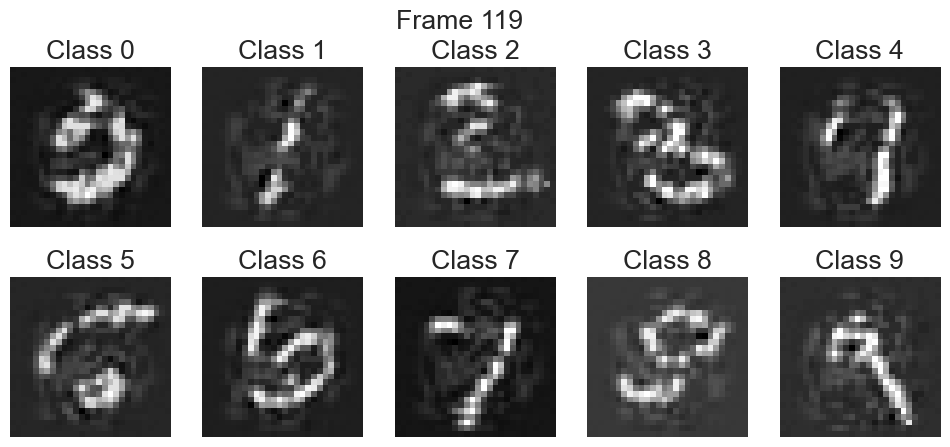

In [12]:
for frac_keep in [0.75, 0.5, 0.25]:
    print('\n' + '='*60)
    print(f'Random mask keep fraction = {frac_keep:.2f}')
    print('='*60)
    m = mask_random(frac_keep=frac_keep, seed=7)
    x_mask = broadcast_mask(m, B=len(x_batch))
    x_masked = x_batch * x_mask
    pcn.complete_input(x_masked, x_mask, y_batch, num_steps=120, image_dims=(28, 28, 1), n_plot_rows=2)

### Results + Takeaways

Observed trend from our completion scenarios:
- Completions are strongest when contiguous structure is still visible (e.g., vertical/horizontal half masks).
- Stripe masks are harder because local continuity is repeatedly broken.
- Random masks degrade sharply as keep fraction drops from 0.75 to 0.25.

In short, DensePCN completion quality depends heavily on how much structured evidence remains in visible pixels, not just the raw percentage of unmasked pixels.

### Extension 1 Conclusion

We completed Extension 1 by testing multiple image completion scenarios (different mask geometries and random-mask strengths) and analyzing how each affected DensePCN reconstruction quality.